# Data Ingestion & The SpatialFeatureExperiment Object (Xenium)

## Introduction

In our previous notebook, we used the `SpatialExperiment` (SPE) object to load Visium HD data. Because Visium HD relies on a perfectly regular grid of spatial bins, storing the spatial data as a simple matrix of $(x, y)$ point coordinates was perfectly sufficient. However, what happens when we move to true single-cell resolution platforms like **10x Genomics Xenium**?

In Xenium data, transcripts are assigned to cells based on **cell segmentation algorithms**. Cells are not perfect squares or circles; they are complex, irregular polygons. Furthermore, Xenium outputs multiple layers of rich spatial information: in addition to the standard count matrix, it provides precise **cell and nucleus boundaries**, exact subcellular **transcript locations**, and high-resolution **morphology images**.

To accurately store, analyze, and plot these complex biological shapes and images, we need a data structure that understands true spatial geometries. This is why the **`SpatialFeatureExperiment` (SFE)** object is key. SFE directly extends the `SpatialExperiment` structure you just learned, adding advanced geometry support so we can easily manipulate these new spatial layers.

### Learning objectives

- Understand the internal structure of a `SpatialFeatureExperiment` object.
- Explain when `SpatialFeatureExperiment` is necessary compared to a standard `SpatialExperiment`.
- Access cell-level metadata and spatial coordinates from Xenium data.
- Inspect complex geometry information, such as precise cell or nucleus boundaries.
- Compare this Xenium data representation with the Visium HD representation from the previous notebook.

### Course dataset (Xenium)

#### Biological origin

For this module, we will be switching to the **10x Xenium** output we prepared during the [dataset assembly phase](./00-assembling_spatial_transcriptomics_datasets.ipynb) (`data/Human_Colon_Cancer_P2/xenium/outs/`).

This dataset comes from the same human colorectal cancer study (Patient 2) by [Oliveira *et al.*](https://doi.org/10.1038/s41588-025-02193-3). However, it is important to note that this Xenium slide is a **serial section** of the Visium sample used in the [previous notebook](./01-data_ingestion_SpatialExperiment_object.ipynb). This means the two datasets are biologically related (adjacent slices of the tumor), but they **do not** contain the exact same physical cells.

#### Subcellular In-Situ transcriptomics

Unlike Visium, which unbiasedly captures the entire transcriptome onto a microarray, imaging-based platforms like Xenium use fluorescent probes to detect a **targeted panel** of genes (a few hundred to a few thousand) directly *in situ*.

By decoding these transcripts at true subcellular resolution, Xenium allows algorithms to draw precise geometric boundaries (segmentations) around individual cells and nuclei.

#### Initial Quality Control

Before loading any data into R, we should always inspect the raw outputs. The **Xenium Analysis Summary** HTML provides an immediate overview of crucial metrics such as total transcripts detected, cell segmentation performance, and optical decoding rates.

We have explicitly included these reports in our prepared data package! We can find them inside the `data/Human_Colon_Cancer_P2/reports/` directory. If we open the Xenium HTML file in our web browser, we will see an interactive dashboard allowing us to explore global metrics and cell overlays before writing any code:

1. Looking at the **Decoding** section, *76.6% of all gene transcripts are high quality*, yielding over 50.5 million total transcripts. Furthermore, the negative control probe rate is exceptionally low (*0.3%*). This confirms that the *in situ* chemistry worked perfectly, and the probes attached to real RNA targets with virtually zero background optical noise.
2. Looking at the **Cell Segmentation** section, the pipeline successfully detected **340,837 cells**. The *median transcripts per cell is 94*. Because Xenium uses a targeted panel rather than capturing the whole transcriptome, the total transcript count per cell is lower than standard scRNA-seq, but the data is exceptionally specific.
3. The interactive **Region Details** map plots transcript density over the physical tissue area. We can visually verify that the high transcript density (the bright green and yellow heatmap regions) beautifully traces the complex, folding glandular morphology of the colon tissue, while empty stromal spaces correctly show very few transcripts.

In [1]:
# Load the raw metrics CSV
xenium_metrics <- read.csv(
  "data/Human_Colon_Cancer_P2/xenium/outs/metrics_summary.csv")

print(as.data.frame(t(xenium_metrics)))

                                                                                        V1
run_name                                                                Human_Colon_Cancer
cassette_name                                                                          N/A
region_name                                               Human_Colon_Cancer_P2_CRC_Add_on
panel_name                                                       Xenium Human Colon Add-on
panel_design_id                                                                        N/A
predesigned_panel_id                                                             hColon_v1
region_area                                                                       42823617
total_cell_area                                                                   21458887
total_high_quality_decoded_transcripts                                            50594830
fraction_transcripts_decoded_q20                                                  0.765543

While the HTML report is highly visual, extracting data directly from the `metrics_summary.csv` reveals a few extra technical details about our experiment:

- **The Panel Identity:** We are using the *Xenium Human Colon Add-on* panel. [10x Genomics designed a base set of genes specifically for colon tissue](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/pre-designed-xenium-v1), and the researchers added custom genes on top of it.
- **Transcript Assignment Rate:** An impressive **83.2%** of all RNA molecules found on this slide were successfully assigned inside a segmented cell polygon. This indicates extremely clean data with very little "free-floating" ambient background RNA.
- **Tissue Density:** The total imaged region is ~42,823,616 µm² (or ~42.8 mm²), but the segmented cells only take up ~21.5 mm². This tells us that roughly half of the imaging rectangle is empty space or extracellular stroma, perfectly matching the visual gaps we saw in the HTML heatmap.
- **Z-Thickness:** Xenium actually images the tissue in 3D (Z-stacks). This metric tells us the optical thickness of the tissue section where high-quality transcripts were found is **6.42 µm**.

## Environment setup

### Loading libraries

In [2]:
suppressPackageStartupMessages({
  # Core spatial packages
  library(SpatialFeatureExperiment)
  library(SpatialExperiment) # Required to expose the assay() function
  library(HDF5Array)

  # Visualization packages
  library(Voyager)
  library(ggplot2)
  library(patchwork)
})

### Loading the dataset

Recall that raw 10x Genomics outputs are incredibly massive. During the data preparation phase (["Assembling the Spatial Transcriptomics Datasets"](./00-assembling_spatial_transcriptomics_datasets.ipynb)), we cropped the original whole-slide output down to a highly specific, morphology-rich Region of Interest (ROI) and stripped away unnecessary raw matrices to create a lightweight, optimized course dataset.

This compact dataset is already sitting locally in our `data/Human_Colon_Cancer_P2/xenium/outs` directory. The code block below runs a quick sanity check to verify that R can locate these assembled files before we attempt to import them.

In [3]:
# Define the path to our subsetted Xenium course dataset
data_dir <- "data"
human_colon_cancer_xenium_dir <- file.path(
  data_dir, "Human_Colon_Cancer_P2", "xenium", "outs")

# Sanity check: Ensure the dataset was generated in the previous notebook
if (!dir.exists(human_colon_cancer_xenium_dir)) {
  stop(
    "Xenium data directory not found! \n",
    "Please ensure we have successfully run the '00-assembling' notebook ",
    "to generate the 'data/Human_Colon_Cancer_P2/xenium/outs' folder before proceeding."
  )
} else {
  message("Xenium dataset found successfully! We are ready to proceed.")
}

Xenium dataset found successfully! We are ready to proceed.



### Importing the SpatialFeatureExperiment Object

To load our data, we will use the `readXenium()` function. Much like the import function we used for Visium HD, this command automatically parses the complex folder structure (including the count matrices and cell boundaries) and safely packages everything into a single object in our R environment.

However, there is one critical technical detail to be aware of: **coordinate systems**. We will import the Xenium output using the argument `flip = "none"`. This ensures that we load the data using Xenium's native _coordinate orientation_. As we saw in the [data preparation notebook](./00-assembling_spatial_transcriptomics_datasets.ipynb), Xenium's native coordinate system actually differs from the one used by the Visium HD platform. While we *could* flip the coordinates right now at the import stage to force them to match Visium, we chose to keep them in their native state for this practical so we can learn how to account for this discrepancy during the visualization steps.

In [4]:
# Import the Xenium output into a SpatialFeatureExperiment (SFE) object
sfe <- readXenium(
  data_dir = human_colon_cancer_xenium_dir, 
  flip = "none"
)

Warning message in .get_xenium_images(data_dir, image, major_version, flip, max_flip, :
"morphology_focus images not found"
>>> Preprocessed sf segmentations found
>>> Reading cell and nucleus segmentations

>>> Reading cell metadata -> `cells.parquet`

>>> Reading h5 gene count matrix

>>> filtering cellSeg geometries to match 340837 cells with counts > 0

>>> filtering nucSeg geometries to match 326946 cells with counts > 0



>Remember that in the Visium HD notebook, we used a two-step process: `TENxVisiumHD()` followed by `import()`. The creators of the `SpatialFeatureExperiment` package built direct, all-in-one functions (`readXenium`, `readVizgen`, `readCosMX`) that specifically know how to parse complex geometric `.parquet` files and build the spatial object in a single step, bypassing the need for a separate `import()` command.

In [5]:
# View a high-level summary of the object
sfe

class: SpatialFeatureExperiment 
dim: 541 340837 
metadata(1): Samples
assays(1): counts
rownames(541): ENSG00000006071 ENSG00000102575 ...
  UnassignedCodeword_0330 UnassignedCodeword_0338
rowData names(3): ID Symbol Type
colnames(340837): aaaadaba-1 aaaadgga-1 ... oikdmkkf-1 oikeebja-1
colData names(9): transcript_counts control_probe_counts ...
  nucleus_area sample_id
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : x_centroid y_centroid
imgData names(0):

unit: micron
Geometries:
colGeometries: centroids (POINT), cellSeg (MULTIPOLYGON), nucSeg (MULTIPOLYGON) 

Graphs:
sample01: 

If we look closely at the summary output of our newly imported `sfe` object, we will notice that the `rownames` are currently Ensembl IDs (e.g., `ENSG00000006071`). Just like with our Visium HD data, standard 10x Genomics `.h5` matrices default to these machine-readable IDs. Because it is much easier for us to work with human-readable Gene Symbols during our analysis, our immediate next step is to replace the rownames using the `uniquifyFeatureNames()` function.

In [6]:
# Convert rownames from Ensembl IDs to unique Gene Symbols
rownames(sfe) <- scuttle::uniquifyFeatureNames(
  ID = rowData(sfe)$ID,
  names = rowData(sfe)$Symbol
)

# Preview the first few rownames to verify the change
rownames(sfe) |> head()

[1] "ABCC8"   "ACP5"    "ACTA2"   "ADH1C"   "ADRA2A"  "AFAP1L2"

### Subsetting to the ROI

If we look at the dimensions of our `sfe` object, we can see exactly how massive this Xenium dataset is. The dimensions are `541` rows by `340,837` columns. Unlike Visium HD, which uses arbitrary spatial "bins", Xenium's columns represent true segmented cells. This means our object contains **541 targeted genes** measured across **340,837 individual cells**!

For practical reasons, we will subset our object down to a much smaller Region of Interest (ROI). Specifically, we have selected coordinate bounds that **approximately match the glandular region we analyzed in the previous Visium HD notebook**. This makes the two datasets visually comparable without forcing us to run a heavy, mathematically complex image-registration workflow today (like the process explained in detail in [this section from the OSTA book](https://lmweber.org/OSTA/pages/crs-workflow-xenvis.html#alignment)).

*(Note: These exact coordinate boundaries were optimized during our previous data assembly phase and are formally documented in the `README.md` file located inside the dataset folder).*

In [7]:
# Define the Xenium ROI boundaries
roi_xenium <- c(
  xmin = 2200, 
  xmax = 4500, 
  ymin = 2500, 
  ymax = 4900)

In [8]:
# Extract the spatial coordinates
coords <- spatialCoords(sfe)

# Create a simple True/False filter for cells whose centroids fall inside our box
in_roi <- coords[, 1] >= roi_xenium[["xmin"]] & 
          coords[, 1] <= roi_xenium[["xmax"]] & 
          coords[, 2] >= roi_xenium[["ymin"]] & 
          coords[, 2] <= roi_xenium[["ymax"]]

# Subset the object (keeping the cell polygons perfectly intact!)
sfe <- sfe[, in_roi]

# Clean up our temporary variables and free up RAM
#gc()

To avoid destroying the biological morphology of the cells on the edges of our ROI, we will use standard logical subsetting instead. By filtering based on the `spatialCoords` (which represent the exact *center point* of each cell), we ensure that if a cell's centroid falls inside our box, the **entire, intact cell polygon** is kept. 

>The `SpatialFeatureExperiment` package actually has a built-in `crop()` function that can subset data using a bounding box. However, `crop()` acts like a mathematical cookie cutter: if a cell sits exactly on the border of the bounding box, `crop()` will physically slice the cell polygon in half...

In [9]:
# Print the object to see the newly reduced dimensions
sfe

class: SpatialFeatureExperiment 
dim: 541 52569 
metadata(1): Samples
assays(1): counts
rownames(541): ABCC8 ACP5 ... UnassignedCodeword_0330
  UnassignedCodeword_0338
rowData names(3): ID Symbol Type
colnames(52569): ablhnkec-1 ablhpkkh-1 ... oikdmkkf-1 oikeebja-1
colData names(9): transcript_counts control_probe_counts ...
  nucleus_area sample_id
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : x_centroid y_centroid
imgData names(0):

unit: micron
Geometries:
colGeometries: centroids (POINT), cellSeg (MULTIPOLYGON), nucSeg (MULTIPOLYGON) 

Graphs:
sample01: 

## Anatomy of a SpatialFeatureExperiment object

### The single-cell foundation (shared with SPE)

Because the `SpatialFeatureExperiment` (SFE) class is built directly on top of the `SpatialExperiment` (SPE) structure, almost everything we learned in the previous Visium HD notebook still applies.

For example, our Xenium object still has:

- **`colData()`**: Containing cell-level metadata (like transcript counts and nucleus area).
- **`rowData()`**: Containing gene-level metadata (like Ensembl IDs and Symbols).
- **`assays()`**: Containing our out-of-memory `DelayedMatrix` of UMI counts.
- **`spatialCoords()`**: Containing the X/Y centroids of each cell.

In [10]:
# Inspect the first few rows of cell-level metadata
colData(sfe) |> head()

DataFrame with 6 rows and 9 columns
           transcript_counts control_probe_counts control_codeword_counts
                   <integer>            <integer>               <integer>
ablhnkec-1               116                    0                       0
ablhpkkh-1               120                    0                       0
ablicbjh-1                89                    0                       0
ablilfnl-1                81                    0                       0
ablineen-1               145                    0                       0
ablioegm-1                71                    0                       0
           unassigned_codeword_counts deprecated_codeword_counts total_counts
                            <integer>                  <integer>    <integer>
ablhnkec-1                          0                          0          116
ablhpkkh-1                          0                          0          120
ablicbjh-1                          0                       

Instead of physical DNA barcodes, the rownames (e.g., `ablhnkec-1`) are simply unique alphabetical IDs generated by the image segmentation algorithm. And because this segmentation provides true single-cell resolution, our metadata contains actual physical measurements for each individual cell, such as `cell_area` and `nucleus_area`.

In [11]:
# Inspect the gene metadata
rowData(sfe) |> head()

DataFrame with 6 rows and 3 columns
                     ID      Symbol            Type
            <character> <character>     <character>
ABCC8   ENSG00000006071       ABCC8 Gene Expression
ACP5    ENSG00000102575        ACP5 Gene Expression
ACTA2   ENSG00000107796       ACTA2 Gene Expression
ADH1C   ENSG00000248144       ADH1C Gene Expression
ADRA2A  ENSG00000150594      ADRA2A Gene Expression
AFAP1L2 ENSG00000169129     AFAP1L2 Gene Expression

If we look back at the summary of the `sfe` object we printed in a previous step, we may have noticed the line `assays(1): counts`. Right now, our object only contains this single raw counts matrix. Later in the course, when we normalize the data, a second matrix called `"logcounts"` will be added here.

>Even though we are working with `SpatialFeatureExperiment` today, we still explicitly load the base `SpatialExperiment` package. This is because the SFE package occasionally forgets to "pass through" certain foundational functions to the user, such as the `assay()` function we will use later to view our count matrix!

In [12]:
# Print a preview of the actual count matrix
assay(sfe, "counts")

<541 x 52569> sparse DelayedMatrix object of type "integer":
                        ablhnkec-1 ablhpkkh-1 ablicbjh-1 ... oikdllpb-1
                  ABCC8          0          0          0   .          0
                   ACP5          0          0          1   .          0
                  ACTA2          1          0          0   .          0
                  ADH1C          0          0          0   .          0
                 ADRA2A          0          0          0   .          0
                    ...          .          .          .   .          .
UnassignedCodeword_0289          0          0          0   .          0
UnassignedCodeword_0292          0          0          0   .          0
UnassignedCodeword_0298          0          0          0   .          0
UnassignedCodeword_0330          0          0          0   .          0
UnassignedCodeword_0338          0          0          0   .          0
                        oikdmkkf-1 oikeebja-1
                  ABCC8      

If we look closely at the `assays` matrix, we will see a detailed breakdown of exactly *how many* copies of each gene were detected in a specific cell. If we were to mathematically sum an entire column in this matrix (adding up all 541 genes for a single cell), that final number would exactly match the `transcript_counts` value we saw earlier in the `colData`.

**How does an image become a count matrix?**

Since Xenium is an image-based technology, it might seem surprising that we end up with a digital matrix of counts.

1. **Amplification:** Probes bound to RNA in the tissue are amplified into tiny "nanoballs" that stay exactly where the original RNA was.
2. **Optical Decoding:** The instrument performs cyclic imaging. In each cycle, fluorescent tags are introduced, imaged, and washed away.
3. **Barcoding:** A single transcript spot will show a specific sequence of colors across the cycles (e.g., Blue → Red → Green). This sequence forms a unique optical barcode.
4. **Counting:** The instrument's software detects these spots across the image stack, reads their barcode, and matches it to a known gene codebook. Every successful match becomes a digital count (a `1`) in our `assays` matrix!

Additionally, the summary of our `sfe` object indicates that the `reducedDims` slot is completely empty (`reducedDimNames(0)`), simply because we have only just imported the raw data and not performed any dimensionality reduction yet.

In [13]:
# Inspect the spatial coordinates (centroids) for the first few cells
spatialCoords(sfe) |> head()

,x_centroid,y_centroid
ablhnkec-1,3422.334,2507.607
ablhpkkh-1,3416.419,2512.555
ablicbjh-1,3428.145,2502.129
ablilfnl-1,3437.918,2514.156
ablineen-1,3430.172,2518.024
ablioegm-1,3447.884,2615.741


If we recall the summary of our object that we printed earlier, it contained the lines `spatialCoords names(2) : x_centroid y_centroid`, `imgData names(0):`, and `unit: micron`. Based on that printout and the coordinates above, we can make two important observations that differ from our Visium data:

1. **Physical Units:** The object summary explicitly states `unit: micron`. This means the numbers in `spatialCoords` are real-world physical distances (microns), not pixels.
2. **No Image Data:** The object summary also showed `imgData names(0)`. While Xenium instruments do take pictures (like DAPI stains), these high-resolution images are absolutely massive. Because we have exact coordinates and precise cell boundary polygons, we can reconstruct the tissue map without needing to load a heavy background image.

### The Geometry extensions (unique to SFE)

What makes SFE special are its **Geometry Extensions**.

![Overview of the `SpatialFeatureExperiment` class structure](../assets/img/sfe.png)

Unlike Visium's arbitrary grid, Xenium provides complex mathematical polygons representing the exact physical boundaries of every cell and nucleus. SFE stores these boundaries using the `sf` (Simple Features) R package, treating our tissue like a geographic map.

These shapes are stored in a specialized slot called **`colGeometries`** (column geometries, because each polygon perfectly corresponds to a "column", or cell, in our count matrix).

The specific geometries available depend on the imaging-based technology and the reader function used to import the data. In our Xenium dataset, these geometries represent the cell centroids (`centroids`), cell boundaries (`cellSeg`), and nucleus boundaries (`nucSeg`).

In [14]:
# List the available geometry extensions in our object
colGeometries(sfe)
#colGeometryNames(sfe)

List of length 3
names(3): centroids cellSeg nucSeg

Because these are stored as "Simple Features" objects, they encode spatial data in a standardized format that we can easily manipulate, intersect, and plot using the popular [sf package](https://r-spatial.github.io/sf/index.html).

In [15]:
# Extract the cell boundary polygons
cell_boundaries <- colGeometry(sfe, "cellSeg")
#cell_boundaries <- colGeometries(sfe)[["cellSeg"]]

# Inspect the first few rows
# We convert it to a data frame to force plain-text printing
# not a geojson object taht requires the geojsonio library
head(as.data.frame(cell_boundaries))

,label_id,polygon_area,geometry
,<int>,<dbl>,<MULTIPOLYGON>
ablhnkec-1,2485,72.18215,MULTIPOLYGON (((3420.188 25...
ablhpkkh-1,2486,69.38192,MULTIPOLYGON (((3416.15 250...
ablicbjh-1,2487,56.15191,MULTIPOLYGON (((3427.413 24...
ablilfnl-1,2488,127.33954,MULTIPOLYGON (((3434 2507.2...
ablineen-1,2489,70.66831,MULTIPOLYGON (((3429.75 251...
ablioegm-1,2490,41.83700,MULTIPOLYGON (((3447.6 2610...


Instead of a single number, each row in the `geometry` column contains a `MULTIPOLYGON` object. This is a mathematical list of the exact X and Y coordinates that draw the border of that specific cell.

>We wrapped our `cell_boundaries` in `as.data.frame()` before printing, because by default, Jupyter tries to automatically draw interactive maps whenever it sees a spatial object. By forcing it into a plain data frame, we bypass this behavior so we can safely inspect the raw coordinates underneath.

## Visualizing the tissue region

Now that we understand the internal structure of our `SpatialFeatureExperiment` object, let's visually explore our tissue section.

### Mapping the tissue with centroids

We can start with a simple scatterplot to map out the physical locations of all the cells in our selected ROI. To do this, we will extract the spatial coordinates (the cell centroids) and simply use `ggplot2`.

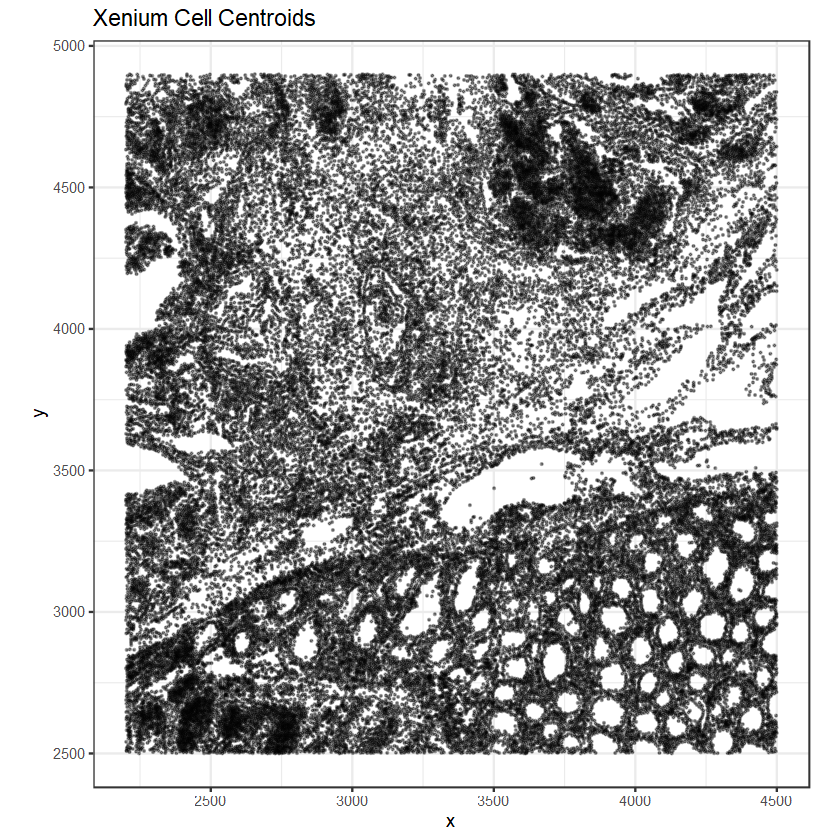

In [16]:
# Extract spatial coordinates and convert to a data frame for ggplot
xy <- as.data.frame(spatialCoords(sfe))
names(xy)[1:2] <- c("x", "y")

# Plot the cell centroids
ggplot(xy, aes(x = x, y = y)) + 
  geom_point(size = 0.08, alpha = 0.4) + 
  coord_fixed() + 
  theme_bw() + 
  labs(x = "x", y = "y", title = "Xenium Cell Centroids")

If we zoom in on the plot, we might notice regions where the cell centroids heavily overlap. Remember that our tissue slice has a physical 3D thickness (roughly 6.4 µm). Cells can be partially stacked on top of each other in the Z-axis! When we flatten these 3D locations into a 2D plot, their coordinates overlap. Additionally, in densely packed epithelial regions, plotting fixed-size dots will visually blur the cells together.

### Correcting the coordinate orientation

If we compare the shape of the tissue in our centroid plot to the Visium HD plot from the previous notebook, we will immediately notice that the image is flipped. Because we imported our data using the argument `flip = "none"`, we are seeing Xenium's raw, _native coordinate system_. Visium HD and Xenium instruments natively orient their coordinate axes differently.

*(Note: In a real-world pipeline, we would typically align and flip these coordinates automatically during the data preparation or import phase, as we briefly saw in the ["Assembling the Spatial Transcriptomics Datasets" notebook](./00-assembling_spatial_transcriptomics_datasets.ipynb). For this exercise, and as a reminder, we intentionally kept them raw so we could understand the discrepancy.)*

We can easily correct this orientation directly at the plotting step by flipping our `x` and `y` mappings.

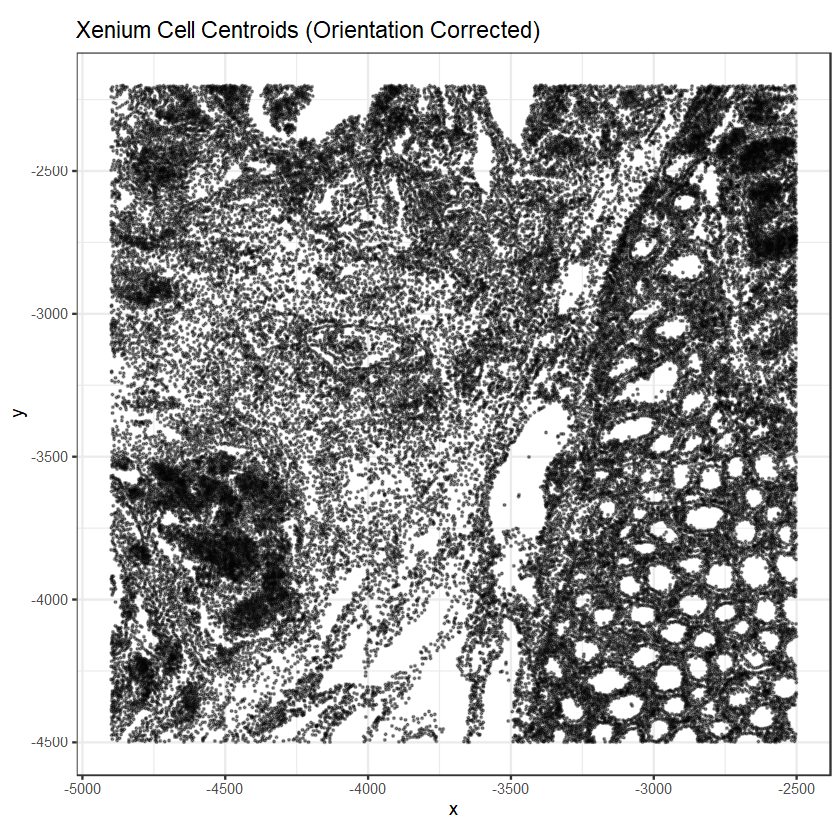

In [17]:
# Plot with flipped coordinates to match the Visium HD orientation
ggplot(xy, aes(x = -y, y = -x)) +
  geom_point(size = 0.08, alpha = 0.4) +
  coord_fixed() +
  theme_bw() +
  labs(x = "x", y = "y", title = "Xenium Cell Centroids (Orientation Corrected)")

### Plotting gene expression _in situ_

We can also visualize the spatial expression of specific marker genes. For example, `PIGR` (Polymeric Immunoglobulin Receptor) is present in our targeted Xenium panel and shows a clear spatial pattern in the colon epithelium.

Because we renamed our object's rows to Gene Symbols after import, we can refer to this marker simply as `"PIGR"`. Note that we will plot raw molecule counts (`exprs_values = "counts"`) for now, as log-normalized counts will be introduced later in the course.

The `plotSpatialFeature()` function from the `Voyager` package makes mapping gene expression very easy.

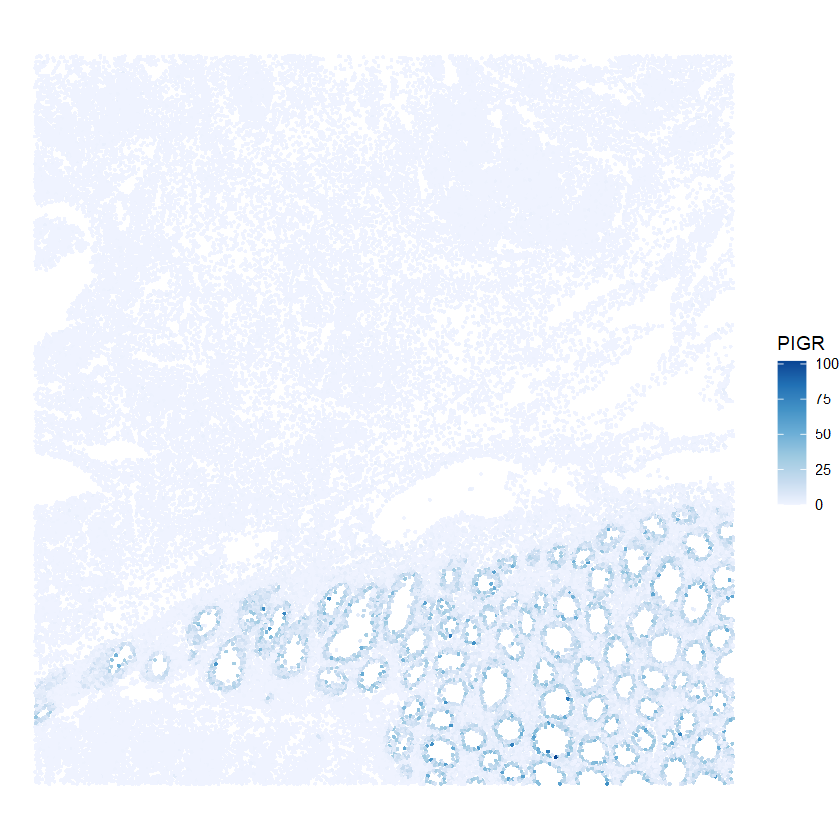

In [18]:
# Plot the raw spatial counts for PIGR
plotSpatialFeature(sfe, "PIGR", exprs_values = "counts")

If we zoom closely into the plot we just generated, we will notice that we are no longer looking at dots or 16 µm square representations of spatial bins. We are looking at precise, irregular shapes! Because we passed a `SpatialFeatureExperiment` object to `Voyager`, the package automatically detected our `cellSeg` geometry and used the true cell polygons to build the map.

### Exploring the gene panel

Because Xenium is a targeted technology, we cannot blindly plot any gene we want; we must first ensure it was actually included in the chemical panel.

If we look back at the raw Xenium output folder, the exact panel design is documented in a file named `gene_panel.json`. However, since we have already loaded the data into our `sfe` object, the absolute easiest way to check the panel is by looking at our `rownames`.

In [19]:
# View the first 50 genes available in our panel
rownames(sfe) |> head(n=100)

[1] "ABCC8"    "ACP5"     "ACTA2"    "ADH1C"    "ADRA2A"   "AFAP1L2" 
  [7] "AGTR1"    "AKR1C3"   "AKR7A3"   "ALDH1B1"  "ANK2"     "ANO7"    
 [13] "ANPEP"    "ANXA1"    "ANXA13"   "APOC1"    "APOE"     "AQP1"    
 [19] "AQP8"     "AREG"     "ARHGAP24" "ARX"      "ASCL2"    "ATOH1"   
 [25] "ATP5F1E"  "AVIL"     "AXIN2"    "AZGP1"    "B3GNT6"   "BANK1"   
 [31] "BATF"     "BCAS1"    "BEST2"    "BEST4"    "BMP4"     "BMX"     
 [37] "BRCA2"    "C1QA"     "C1QB"     "C1QBP"    "C1QC"     "C2orf88" 
 [43] "C3"       "C3AR1"    "CA1"      "CA2"      "CA4"      "CA7"     
 [49] "CADPS"    "CALB2"    "CCL19"    "CCL20"    "CCL4"     "CCL5"    
 [55] "CCR1"     "CCR7"     "CD14"     "CD163"    "CD177"    "CD2"     
 [61] "CD24"     "CD27"     "CD274"    "CD3D"     "CD3E"     "CD3G"    
 [67] "CD40LG"   "CD5"      "CD6"      "CD68"     "CD69"     "CD7"     
 [73] "CD79A"    "CD79B"    "CD83"     "CD8A"     "CD8B"     "CDCA7"   
 [79] "CDH5"     "CDHR5"    "CDK15"    "CDK6"     "CDKN2B"   "CEACAM1" 
 [85] "CEACAM5"  "CEACAM6"  "CEACAM7"  "CEP126"   "CES1"     "CES2"    
 [91] "CFTR"     "CHGA"     "CHGB"     "CHI3L1"   "CHI3L2"   "CHP2"    
 [97] "CKAP4"    "CLCA1"    "CLCA4"    "CLEC10A"

In [20]:
# Check if a specific gene (like MUC2) is present in the panel
"MUC2" %in% rownames(sfe)

[1] FALSE

Because `MUC2` returns `FALSE`, we know we cannot plot it. Instead, let's choose a few genes that are actively present in the panel (`PIGR`, `CEACAM5`, `ACTA2`, and `CD3E`) and pass them as a list to our plotting function. `Voyager` will automatically generate a faceted grid for us, allowing us to visualize the spatial distribution of several different cell types simultaneously.

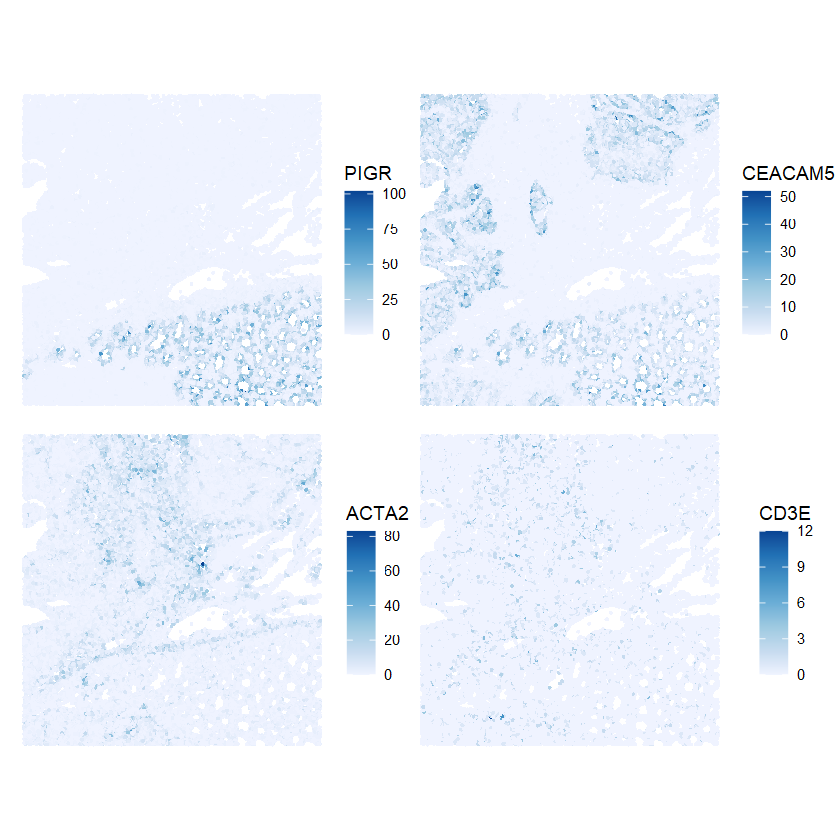

In [21]:
# Plot a grid of multiple marker genes simultaneously
plotSpatialFeature(
  sfe, 
  features = c("PIGR", "CEACAM5", "ACTA2", "CD3E"), 
  exprs_values = "counts")

If we look closely at the resulting grid, we can observe distinct biological compartments:

- **The Epithelium (`PIGR` & `CEACAM5`):** `PIGR` highlights the highly organized, healthy glandular structures in the bottom-right corner. `CEACAM5` also marks the epithelium but is highly overexpressed in the upper region, mapping perfectly to the cancerous tumor mass.
- **The Stroma (`ACTA2`):** Notice how `ACTA2` traces the fibrous stroma and smooth muscle bands, perfectly wrapping around and separating the epithelial glands.
- **Immune Infiltration (`CD3E`):** Rather than forming solid structures, `CD3E` reveals individual, scattered T-lymphocytes infiltrating the stroma and tumor microenvironment. This is the true power of single-cell spatial resolution!

### Comparing resolution: Visium HD vs. Xenium

To truly appreciate the power of Xenium, it helps to view it side-by-side with Visium HD. There are two major conceptual differences between the platforms:

1. **Resolution:** The Visium HD signal aggregates molecules within fixed 16µm spatial bins, blurring single-cell boundaries. The Xenium signal is measured directly over true segmented cells, revealing genuine **cell-level heterogeneity**. For instance, in our previous plot, we could clearly spot individual `CD3E` T-cells infiltrating the tissue. In Visium HD, the signal from those tiny T-cells would be blended together with the surrounding stroma inside a single bin.
2. **Targeting:** Visium HD captures the entire unbiased transcriptome. Xenium provides superior physical resolution but only measures a predefined targeted panel of genes.

>As we briefly saw back in the data preparation notebook, microscope images have their `(0,0)` origin at the **top-left** corner (Y increases as we go *down*). However, `ggplot2` is a mathematical plotter, so it puts its `(0,0)` origin at the **bottom-left** (Y increases as you go *up*).
>
>Because of this, if we directly plot our Visium coordinates using `y = y`, `ggplot2` will draw the tissue completely upside down! To fix this and restore the orientation we saw in the previous notebook, we simply map our Y-axis as `y = -y`.

In [22]:
options(repr.plot.width = 12, repr.plot.height = 6)

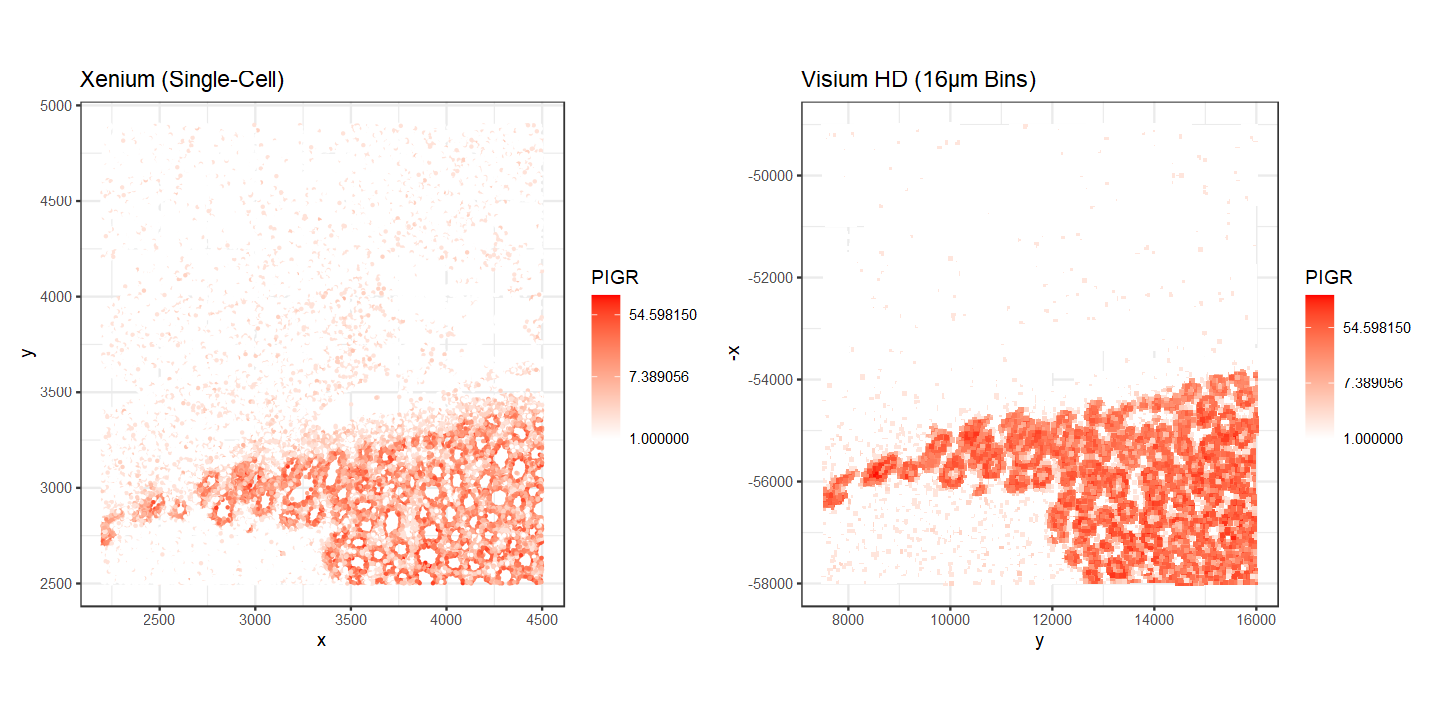

In [23]:
# Prepare Xenium Data
# Combine our spatial data, metadata, and gene expression into a single flat data frame
xy_xen <- data.frame(
  spatialCoords(sfe),               # Add the physical cell coordinates
  colData(sfe),                     # Add the cell-level metadata
  PIGR = counts(sfe)["PIGR", ] + 1  # Add raw counts (+1 pseudocount to avoid log(0) errors)
)

# Rename the first two coordinate columns from 'x_centroid'/'y_centroid' to simply 'x' and 'y'
# (Keeping the native orientation we've used so far)
names(xy_xen)[1:2] <- c("x", "y")

# Build the Xenium plot
p_xen <- ggplot(xy_xen, aes(x = x, y = y, color = PIGR)) + 
  geom_point(size = 0.2) +              # Draw cells as tiny dots
  coord_fixed() +                       # Lock aspect ratio so tissue isn't stretched
  # Apply log-transformed color scale
  scale_color_gradient(trans = "log", low = "white", high = "red") + 
  theme_bw() +                          # Use a clean white background
  labs(title = "Xenium (Single-Cell)")  # Add the plot title


# Prepare Visium HD Data (Loading our object from the output directory)
spe <- loadHDF5SummarizedExperiment(
  dir = "output/", prefix = "spe_visiumHD_CRC_P2_filtered_")

xy_vis <- data.frame(
  spatialCoords(spe),
  colData(spe),
  PIGR = counts(spe)["PIGR", ] + 1)

names(xy_vis)[1:2] <- c("x", "y")

# Notice we map x = y, y = -x to rotate and flip the Visium tissue 
# so it visually aligns perfectly with our Xenium plot
p_vis <- ggplot(xy_vis, aes(x = y, y = -x, color = PIGR)) + 
  geom_point(size = 1, shape = 15) + 
  coord_fixed() + 
  scale_color_gradient(trans = "log", low = "white", high = "red") + 
  theme_bw() + 
  labs(title = "Visium HD (16µm Bins)")

# Plot them side-by-side
p_xen + p_vis

If we look closely at our side-by-side comparison, the difference in physical resolution becomes glaringly obvious. In the Xenium plot (left), the hollow interiors (lumens) of the individual glandular structures are crisp and clear. In the Visium HD plot (right), the larger 16µm bins blur these fine boundaries together, making the interior of the glands look blocky and far less apparent.

### Visualizing true cell shapes

The scatterplots above only show the *centroids* (a single point) for each cell. To see the true morphological shapes of the cells and nuclei, we need to map the actual mathematical polygons stored in the `colGeometries` slot. We can visualize these complex shapes by passing the geometry names we discovered earlier directly into the `colGeometryName` argument of `plotSpatialFeature()`.

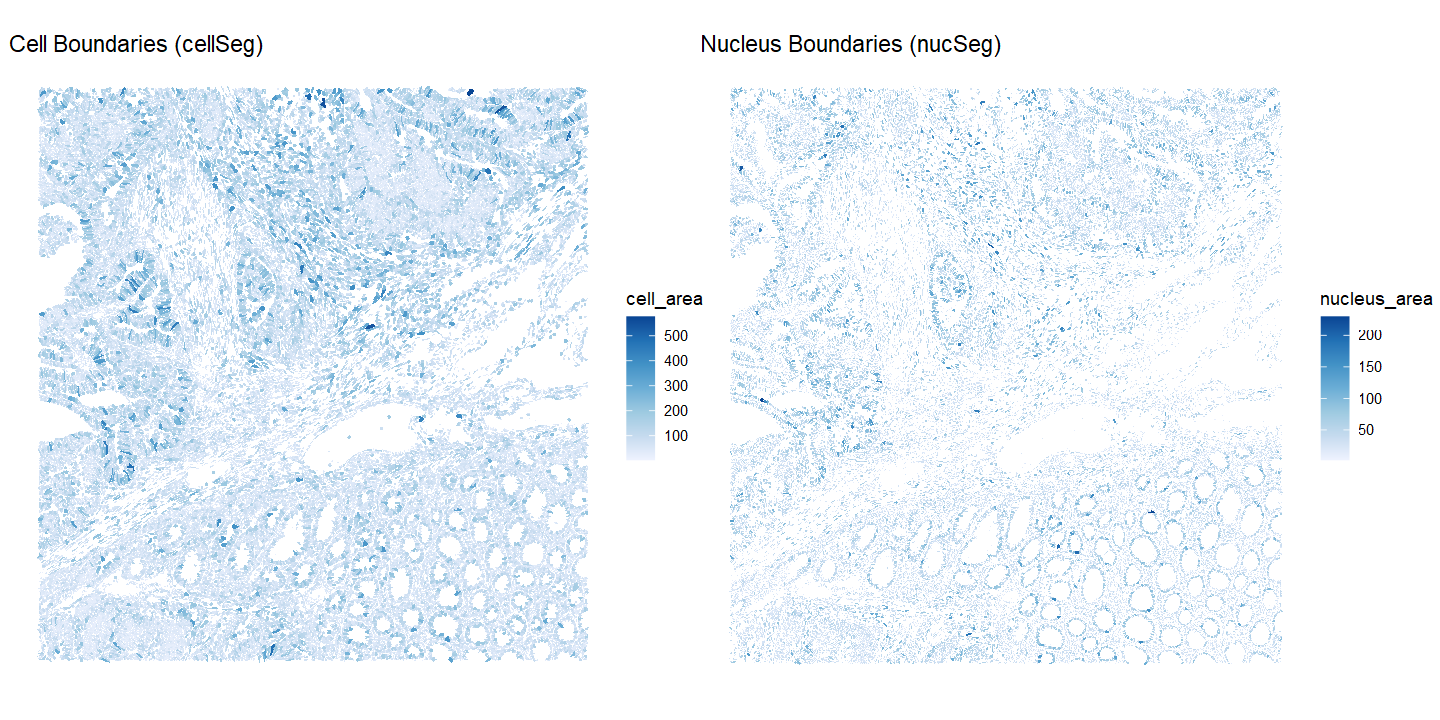

In [24]:
# Plot the cell boundaries colored by physical cell area
p_cell <- plotSpatialFeature(
  sfe, 
  colGeometryName = "cellSeg", 
  features = "cell_area") + 
  labs(title = "Cell Boundaries (cellSeg)")

# Plot the nuclear boundaries colored by physical nucleus area
p_nuc <- plotSpatialFeature(
  sfe, 
  colGeometryName = "nucSeg", 
  features = "nucleus_area") + 
  labs(title = "Nucleus Boundaries (nucSeg)")

# Combine them side-by-side using patchwork
p_cell + p_nuc

If we look closely at the `cellSeg` plot, we can notice striking differences in cell sizes. We can easily spot the elongated epithelial cells lining the mucosa, and even resolve the individual cells wrapping around the glands! This variation in `cell_area` is driven by a mix of **biology** (different cell types natively vary in size, and tumor cells often exhibit enlarged, irregular shapes) and **technology** (our 2D slice cuts through 3D cells at different angles, and automated segmentation algorithms can occasionally under- or over-estimate boundaries in densely packed regions).

In contrast, the `nucSeg` (nuclear boundaries) plot is much less informative at this tissue scale. Because nuclei are so tiny, they don't reveal the same rich, interlocking structural shapes that the full cell boundaries do. For this reason, most of our downstream spatial analysis will focus on the `cellSeg` geometry.

## Finalizing the object

### Saving the object

In our previous Visium HD notebook, our final step before saving was to filter out empty spatial bins that fell outside the tissue. Because Xenium data is purely cell-resolved, the segmentation algorithm only generated polygons for actual physical cells, so we don't have an arbitrary grid of "empty" background space to remove.

Moreover, we used `saveHDF5SummarizedExperiment` to safely store our out-of-memory count matrices. However, as we have seen, our new `SpatialFeatureExperiment` object is much more complex and includes multiple mathematical geometry layers. Standard functions like `saveHDF5SummarizedExperiment` struggle to properly write and re-import these `sf` polygons.

To solve this, we will use the `alabaster.sfe` package. This package implements a robust, language-agnostic format designed specifically to safely serialize `SpatialFeatureExperiment` objects (and all their associated geometries) to disk based on the [ArtifactDB project](https://github.com/ArtifactDB). We can find more details in the [package vignette](https://bioconductor.org/packages/3.23/bioc/vignettes/alabaster.sfe/inst/doc/Overview.html).

Because we only need the `alabaster.sfe` package a single time at the very end of our workflow, we didn't load the entire library at the top of the notebook. Instead, we use the `::` operator to temporarily call the `saveObject` function directly from the package namespace. 

Additionally, we are saving the object directly to the `output/` directory at the root of our project. This ensures that our Jupyter kernel places the files in the correct central location, making them easy to find for our next notebook!

In [25]:
# Define our target output directory
out_path <- "output/sfe_xenium"

# If the directory already exists from a previous run, delete it first
if (dir.exists(out_path)) {
  unlink(out_path, recursive = TRUE)
}

# Save the SFE object to disk
alabaster.sfe::saveObject(sfe, out_path)

>>> Saving SpatialExperiment

>>> Saving colgeometries



Unlike standard R objects that save as a single `.rds` file, `alabaster.sfe` saves the data as an entire, highly-organized directory. If we look inside our new `output/sfe_xenium` folder, we will find core metadata files (like `OBJECT` and `_environment.json`) alongside distinct subdirectories such as `assays/`, `column_data/`, and `coordinates/`. This modular directory structure is exactly what makes the ArtifactDB format so powerful—it is language-agnostic and allows future algorithms to load only the specific pieces of the object they actually need.

### Clearing the environment

Before moving on to the next notebook, it is highly recommended to clear our R workspace. Because spatial transcriptomic datasets and their associated geometries are massive, clearing the environment frees up the computer's RAM. It also ensures we are starting the next notebook from a completely clean slate, preventing any old variables from leaking into our new analysis.

*(Note: Depending on the code editor, it is also good practice to completely restart the R Kernel/Session from the menu bar before opening the next notebook).*

In [26]:
# Clear all variables from the R environment
rm(list = ls())

# Run garbage collection to aggressively free up RAM
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13338063,712.4,29174600,1558.1,29174600,1558.1
Vcells,30401556,232.0,95540277,729.0,95540277,729.0
